# Dynamic Optimization with DAE Collocation

Many engineering problems involve **dynamics** --- systems that evolve over time according to differential equations. Examples include:

- **Optimal control**: find inputs that drive a system to a desired state with minimum cost
- **Parameter estimation**: fit kinetic parameters to experimental time-series data
- **Experiment design**: choose operating conditions to maximize information content
- **PDE-constrained optimization**: optimize systems governed by partial differential equations

The `discopt.dae` module transcribes ODE/DAE systems into algebraic constraints using **orthogonal collocation on finite elements** {cite:p}`Biegler2010` or **finite differences**, enabling these problems to be solved as standard NLPs within discopt's existing solver infrastructure.

This tutorial covers:

1. Orthogonal collocation background
2. First-order ODEs (exponential decay, chemical kinetics)
3. Parameter estimation from experimental data
4. Optimal control with piecewise-constant controls
5. Second-order ODEs (harmonic oscillator)
6. Index-1 DAEs (algebraic constraints)
7. Method of lines for 1D PDEs
8. Finite-difference discretization

In [1]:
%matplotlib inline

import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from discopt import Model
from discopt.dae import (
    ContinuousSet,
    DAEBuilder,
    FDBuilder,
    align_time_grid,
    collocation_matrix,
    legendre_roots,
    radau_roots,
)

print("All imports successful")

All imports successful


## 1. Orthogonal Collocation Background

**Orthogonal collocation on finite elements** {cite:p}`Biegler2010` is the workhorse method for
transcribing ODE/DAE systems into algebraic constraints suitable for NLP solvers.
The idea is to divide the time horizon $[t_0, t_f]$ into $N_{fe}$ finite elements,
and within each element approximate the state trajectory as a polynomial that
passes through selected **collocation points**.

### Collocation schemes

Two families of collocation points are commonly used:

- **Radau IIA**: Points are the roots of a shifted Radau polynomial on $[0, 1]$.
  The last point is always $\tau = 1$ (the element boundary), which provides
  automatic $C^0$ continuity between elements. This is the default in discopt.

- **Gauss--Legendre**: Points are the roots of a Legendre polynomial mapped to
  $(0, 1)$. Neither endpoint is included, giving higher-order accuracy but
  requiring explicit continuity constraints.

### Differentiation matrix

Given the full node set $[0, \tau_1, \ldots, \tau_{n_{cp}}]$ (element start plus
collocation points), the **differentiation matrix** $A \in \mathbb{R}^{n_{cp} \times (n_{cp}+1)}$
maps function values at all nodes to derivative values at the collocation points:

$$A_{jk} = L_k'(\tau_j)$$

where $L_k$ is the $k$-th Lagrange basis polynomial through the full node set.
The collocation equation for state $x$ in element $i$ at collocation point $j$ is:

$$\sum_{k=0}^{n_{cp}} A_{jk} \, x_{i,k} = h_i \, f(t_{i,j}, x_{i,j})$$

where $h_i$ is the element width and $f$ is the ODE right-hand side {cite:p}`Cuthrell1987`.

Let's inspect the collocation points and differentiation matrices.

In [2]:
# Radau IIA roots for different numbers of collocation points
for ncp in range(1, 6):
    roots = radau_roots(ncp)
    print(f"Radau ncp={ncp}: {np.array2string(roots, precision=6)}")

print()

# Gauss-Legendre roots
for ncp in range(1, 5):
    roots = legendre_roots(ncp)
    print(f"Legendre ncp={ncp}: {np.array2string(roots, precision=6)}")

print()

# Differentiation matrix for Radau with 3 collocation points
A, w = collocation_matrix(3, "radau")
print("Differentiation matrix A (Radau, ncp=3):")
print(np.array2string(A, precision=4, suppress_small=True))
print(f"\nContinuity weights w: {np.array2string(w, precision=4)}")
print(f"A shape: {A.shape}  (ncp x (ncp+1))")

Radau ncp=1: [1.]
Radau ncp=2: [0.333333 1.      ]
Radau ncp=3: [0.155051 0.644949 1.      ]
Radau ncp=4: [0.088588 0.409467 0.787659 1.      ]
Radau ncp=5: [0.057104 0.276843 0.58359  0.86024  1.      ]

Legendre ncp=1: [0.5]
Legendre ncp=2: [0.211325 0.788675]
Legendre ncp=3: [0.112702 0.5      0.887298]
Legendre ncp=4: [0.069432 0.330009 0.669991 0.930568]

Differentiation matrix A (Radau, ncp=3):
[[-4.1394  3.2247  1.1678 -0.2532]
 [ 1.7394 -3.5678  0.7753  1.0532]
 [-3.      5.532  -7.532   5.    ]]

Continuity weights w: [-0.  0. -0.  1.]
A shape: (3, 4)  (ncp x (ncp+1))


## 2. First-Order ODEs: Exponential Decay

We start with the simplest possible ODE --- exponential decay:

$$\frac{dx}{dt} = -x, \quad x(0) = 1$$

The exact solution is $x(t) = e^{-t}$. We'll solve this as a feasibility problem
(no objective) and compare the collocation solution with the analytical result.

The workflow with `DAEBuilder` is:

1. Create a `Model` and a `ContinuousSet` (time domain + discretization parameters)
2. Create a `DAEBuilder` and declare states with `add_state()`
3. Define the ODE right-hand side with `set_ode()`
4. Call `discretize()` to generate all variables and constraints
5. Solve and extract the solution


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Status: optimal


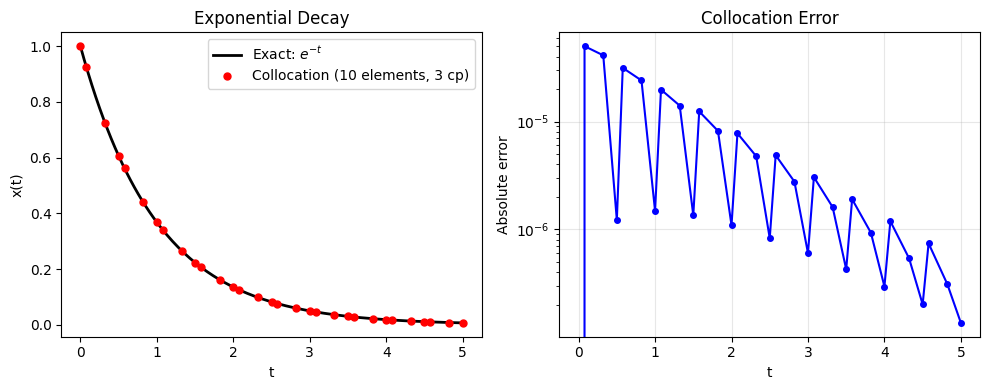

Max absolute error: 5.00e-05


In [3]:
# Model setup
m = Model("exp_decay")
cs = ContinuousSet("t", bounds=(0, 5), nfe=10, ncp=3, scheme="radau")
dae = DAEBuilder(m, cs)

# Declare state with initial condition
dae.add_state("x", initial=1.0, bounds=(0, 2))

# ODE: dx/dt = -x
dae.set_ode(lambda t, states, alg, ctrl: {"x": -states["x"]})

# Discretize and solve (minimize 0 = feasibility problem)
dae.discretize()
m.minimize(0)
result = m.solve()

print(f"Status: {result.status}")

# Extract and plot
t_num, x_num = dae.extract_solution(result, "x")
t_exact = np.linspace(0, 5, 200)
x_exact = np.exp(-t_exact)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(t_exact, x_exact, "k-", label="Exact: $e^{-t}$", linewidth=2)
ax1.plot(t_num, x_num, "ro", markersize=5, label=f"Collocation ({cs.nfe} elements, {cs.ncp} cp)")
ax1.set_xlabel("t")
ax1.set_ylabel("x(t)")
ax1.set_title("Exponential Decay")
ax1.legend()

# Error plot
x_exact_at_nodes = np.exp(-t_num)
error = np.abs(x_num - x_exact_at_nodes)
ax2.semilogy(t_num, error, "bo-", markersize=4)
ax2.set_xlabel("t")
ax2.set_ylabel("Absolute error")
ax2.set_title("Collocation Error")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

max_err = np.max(error)
print(f"Max absolute error: {max_err:.2e}")

## 3. Two-Species Chemical Kinetics

Consider a series reaction $A \xrightarrow{k_1} B \xrightarrow{k_2} C$ governed by:

$$\frac{dA}{dt} = -k_1 A, \qquad \frac{dB}{dt} = k_1 A - k_2 B$$

with initial conditions $A(0) = 1$, $B(0) = 0$ and rate constants $k_1 = 2$, $k_2 = 1$.

The analytical solution is:

$$A(t) = e^{-k_1 t}, \qquad B(t) = \frac{k_1}{k_2 - k_1}\left(e^{-k_1 t} - e^{-k_2 t}\right)$$

This example demonstrates multiple coupled states in the `set_ode()` callback.

Status: optimal


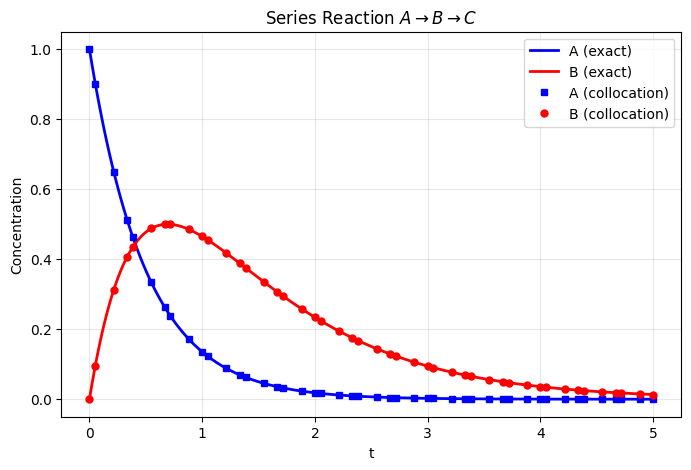

Max error A: 1.41e-04
Max error B: 2.60e-04


In [4]:
k1, k2 = 2.0, 1.0

m = Model("kinetics")
cs = ContinuousSet("t", bounds=(0, 5), nfe=15, ncp=3)
dae = DAEBuilder(m, cs)

dae.add_state("A", initial=1.0, bounds=(0, 2))
dae.add_state("B", initial=0.0, bounds=(0, 2))


def kinetics_rhs(t, states, alg, ctrl):
    A = states["A"]
    B = states["B"]
    return {
        "A": -k1 * A,
        "B": k1 * A - k2 * B,
    }


dae.set_ode(kinetics_rhs)
dae.discretize()
m.minimize(0)
result = m.solve()

print(f"Status: {result.status}")

t_A, A_num = dae.extract_solution(result, "A")
t_B, B_num = dae.extract_solution(result, "B")

# Analytical solutions
t_exact = np.linspace(0, 5, 200)
A_exact = np.exp(-k1 * t_exact)
B_exact = k1 / (k2 - k1) * (np.exp(-k1 * t_exact) - np.exp(-k2 * t_exact))

plt.figure(figsize=(8, 5))
plt.plot(t_exact, A_exact, "b-", linewidth=2, label="A (exact)")
plt.plot(t_exact, B_exact, "r-", linewidth=2, label="B (exact)")
plt.plot(t_A, A_num, "bs", markersize=5, label="A (collocation)")
plt.plot(t_B, B_num, "ro", markersize=5, label="B (collocation)")
plt.xlabel("t")
plt.ylabel("Concentration")
plt.title("Series Reaction $A \\to B \\to C$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Check errors
A_exact_nodes = np.exp(-k1 * t_A)
B_exact_nodes = k1 / (k2 - k1) * (np.exp(-k1 * t_B) - np.exp(-k2 * t_B))
print(f"Max error A: {np.max(np.abs(A_num - A_exact_nodes)):.2e}")
print(f"Max error B: {np.max(np.abs(B_num - B_exact_nodes)):.2e}")

## 4. Parameter Estimation

A common application of dynamic optimization is **parameter estimation**: given
noisy experimental data, find the model parameters that best fit the observations.

We'll estimate the decay rate $k$ from noisy measurements of exponential decay
$dx/dt = -kx$, $x(0) = 1$. The true value is $k = 0.5$.

The optimization problem is:

$$\min_{k, x(\cdot)} \sum_{i} \left(x(t_i) - \hat{x}_i\right)^2 \quad \text{s.t.} \quad \frac{dx}{dt} = -kx, \; x(0) = 1$$

where $\hat{x}_i$ are the noisy measurements at times $t_i$.

Two convenience utilities simplify this workflow:

- `align_time_grid()` adjusts element boundaries so measurement times coincide
  with element boundaries (where collocation nodes exist).
- `DAEBuilder.least_squares()` builds the sum-of-squared-residuals objective
  by mapping each measurement to the nearest collocation node.

Aligned grid: 20 elements


Status: optimal
Estimated k: 0.4836  (true: 0.5)
Relative error: 3.27%


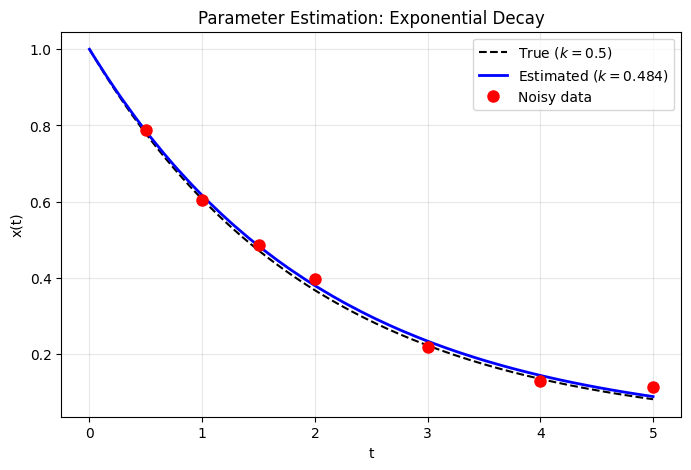

In [5]:
# Generate synthetic noisy data
k_true = 0.5
np.random.seed(42)
t_data = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0])
x_data = np.exp(-k_true * t_data) + 0.02 * np.random.randn(len(t_data))

# Align the time grid so element boundaries include measurement times
eb = align_time_grid(t_span=(0, 5), nfe=20, measurement_times=t_data)
print(f"Aligned grid: {len(eb) - 1} elements")

# Build the estimation problem
m = Model("param_estimation")
cs = ContinuousSet("t", bounds=(0, 5), nfe=len(eb) - 1, ncp=3, element_boundaries=eb)
dae = DAEBuilder(m, cs)

dae.add_state("x", initial=1.0, bounds=(0, 2))

# k is a free parameter to estimate
k = m.continuous("k", lb=0.01, ub=5.0)

# ODE: dx/dt = -k*x (k is a model variable, not a Python constant)
dae.set_ode(lambda t, states, alg, ctrl: {"x": -k * states["x"]})
dae.discretize()

# Build least-squares objective using the convenience method
m.minimize(dae.least_squares("x", t_data, x_data))

result = m.solve()

k_est = result.value(k)
print(f"Status: {result.status}")
print(f"Estimated k: {k_est:.4f}  (true: {k_true})")
print(f"Relative error: {abs(k_est - k_true) / k_true * 100:.2f}%")

# Plot fit vs data
t_sol, x_sol = dae.extract_solution(result, "x")
t_fine = np.linspace(0, 5, 200)

plt.figure(figsize=(8, 5))
plt.plot(t_fine, np.exp(-k_true * t_fine), "k--", linewidth=1.5, label=f"True ($k={k_true}$)")
plt.plot(t_sol, x_sol, "b-", linewidth=2, label=f"Estimated ($k={k_est:.3f}$)")
plt.plot(t_data, x_data, "ro", markersize=8, label="Noisy data")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Parameter Estimation: Exponential Decay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Optimal Control

In optimal control, we seek an input (control) trajectory $u(t)$ that drives a
dynamic system to achieve some objective. Consider the linear system:

$$\frac{dx}{dt} = -x + u, \quad x(0) = 1$$

with the objective of minimizing integrated control effort plus a terminal penalty:

$$\min \int_0^5 u^2 \, dt + 10 \cdot x(5)^2$$

The control $u$ is piecewise constant over each finite element, declared
via `add_control()`. The integral is computed using the collocation quadrature
weights via `dae.integral()` {cite:p}`Betts2010`.

Status: optimal
Objective: 0.0001


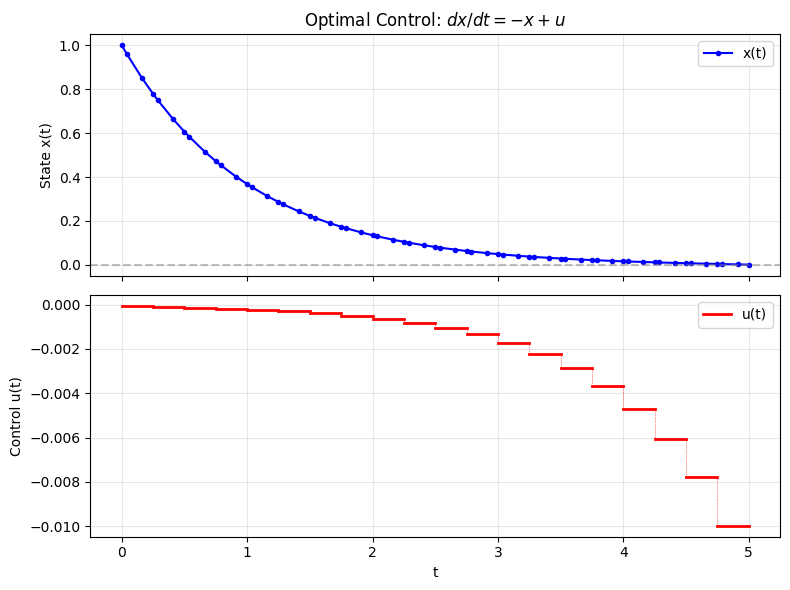

Terminal state x(5) = 0.001128
Terminal penalty: 0.000013


In [6]:
m = Model("optimal_control")
cs = ContinuousSet("t", bounds=(0, 5), nfe=20, ncp=3)
dae = DAEBuilder(m, cs)

dae.add_state("x", initial=1.0, bounds=(-5, 5))
dae.add_control("u", bounds=(-2, 2))

# ODE: dx/dt = -x + u
dae.set_ode(lambda t, states, alg, ctrl: {"x": -states["x"] + ctrl["u"]})
dae.discretize()

# Objective: integral of u^2 + terminal penalty on x(tf)
integral_cost = dae.integral(lambda t, s, a, c: c["u"] ** 2)

x_var = dae.get_state("x")
terminal_penalty = 10.0 * x_var[-1, -1] ** 2

m.minimize(integral_cost + terminal_penalty)

result = m.solve()
print(f"Status: {result.status}")
print(f"Objective: {result.objective:.4f}")

# Extract solution
t_x, x_sol = dae.extract_solution(result, "x")
u_var = dae.get_state("u")
u_sol = result.value(u_var)

# Control is piecewise constant: one value per element
t0, tf = cs.bounds
h = (tf - t0) / cs.nfe
t_u_edges = np.array([t0 + i * h for i in range(cs.nfe + 1)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(t_x, x_sol, "b-o", markersize=3, linewidth=1.5, label="x(t)")
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_ylabel("State x(t)")
ax1.set_title("Optimal Control: $dx/dt = -x + u$")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot piecewise constant control as step function
for i in range(cs.nfe):
    ax2.plot([t_u_edges[i], t_u_edges[i + 1]], [u_sol[i], u_sol[i]], "r-", linewidth=2)
    if i < cs.nfe - 1:
        ax2.plot(
            [t_u_edges[i + 1], t_u_edges[i + 1]], [u_sol[i], u_sol[i + 1]], "r:", linewidth=0.5
        )

ax2.set_xlabel("t")
ax2.set_ylabel("Control u(t)")
ax2.legend(["u(t)"])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Terminal state x(5) = {x_sol[-1]:.6f}")
print(f"Terminal penalty: {10 * x_sol[-1] ** 2:.6f}")

## 6. Second-Order ODEs: Harmonic Oscillator

Many physical systems are naturally described by second-order ODEs.
The **harmonic oscillator** is:

$$\frac{d^2 x}{dt^2} = -x, \quad x(0) = 1, \; \dot{x}(0) = 0$$

with exact solution $x(t) = \cos(t)$.

The `add_second_order_state()` method automatically introduces a velocity
variable and the coupling $dx/dt = v$. The user only needs to supply the
acceleration via `set_second_order_ode()`.

Status: optimal


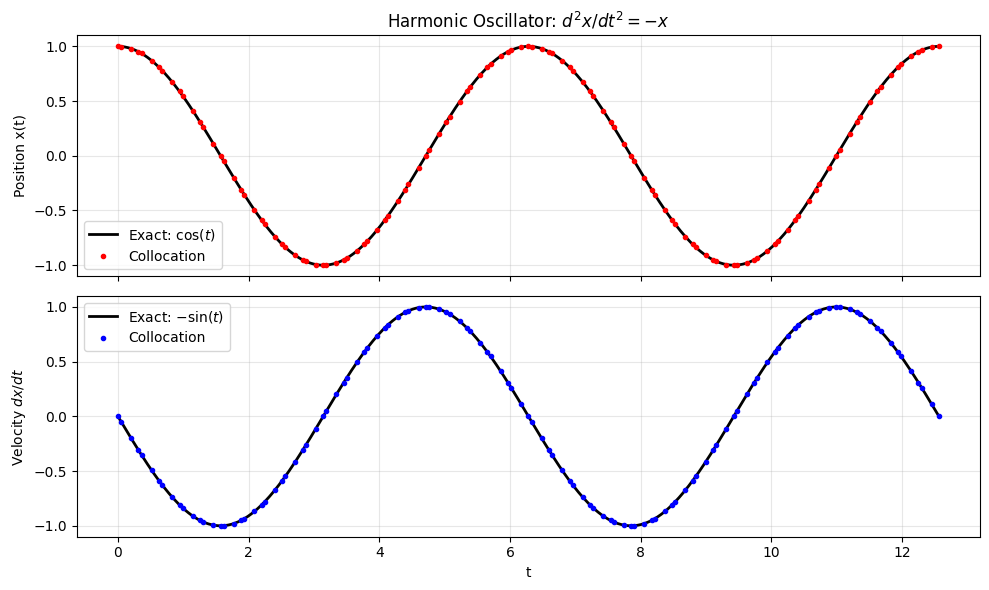

Max position error: 1.32e-05


In [7]:
m = Model("harmonic_oscillator")
cs = ContinuousSet("t", bounds=(0, 4 * np.pi), nfe=40, ncp=3)
dae = DAEBuilder(m, cs)

# Second-order state: position x, automatically creates velocity dx_dt
dae.add_second_order_state(
    "x",
    initial=1.0,  # x(0) = 1
    initial_velocity=0.0,  # dx/dt(0) = 0
    bounds=(-2, 2),
    velocity_bounds=(-2, 2),
)

# Acceleration: d^2x/dt^2 = -x
dae.set_second_order_ode(lambda t, pos, vel, alg, ctrl: {"x": -pos["x"]})

dae.discretize()
m.minimize(0)
result = m.solve()

print(f"Status: {result.status}")

# Extract position and velocity
t_x, x_sol = dae.extract_solution(result, "x")
t_v, v_sol = dae.extract_solution(result, "dx_dt")

t_exact = np.linspace(0, 4 * np.pi, 500)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t_exact, np.cos(t_exact), "k-", linewidth=2, label="Exact: $\\cos(t)$")
ax1.plot(t_x, x_sol, "ro", markersize=3, label="Collocation")
ax1.set_ylabel("Position x(t)")
ax1.set_title("Harmonic Oscillator: $d^2x/dt^2 = -x$")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_exact, -np.sin(t_exact), "k-", linewidth=2, label="Exact: $-\\sin(t)$")
ax2.plot(t_v, v_sol, "bo", markersize=3, label="Collocation")
ax2.set_xlabel("t")
ax2.set_ylabel("Velocity $dx/dt$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

x_exact_nodes = np.cos(t_x)
print(f"Max position error: {np.max(np.abs(x_sol - x_exact_nodes)):.2e}")

## 7. Index-1 DAE

A **differential-algebraic equation** (DAE) couples differential states $x$ with
algebraic variables $z$ that satisfy algebraic (non-differential) constraints.
An **index-1 DAE** has the form:

$$\frac{dx}{dt} = f(x, z), \qquad 0 = g(x, z)$$

where the Jacobian $\partial g / \partial z$ is nonsingular.

Consider the system:

$$\frac{dx}{dt} = -x + z, \qquad 0 = x^2 - z$$

The algebraic constraint forces $z = x^2$ at all times, so the ODE reduces
to $dx/dt = -x + x^2$, which is a Bernoulli equation with known solution.

With `DAEBuilder`, algebraic variables are declared via `add_algebraic()` and
the algebraic equations via `set_algebraic()`. Algebraic variables exist only
at collocation points (not at element boundaries) {cite:p}`Biegler2010`.

Status: optimal


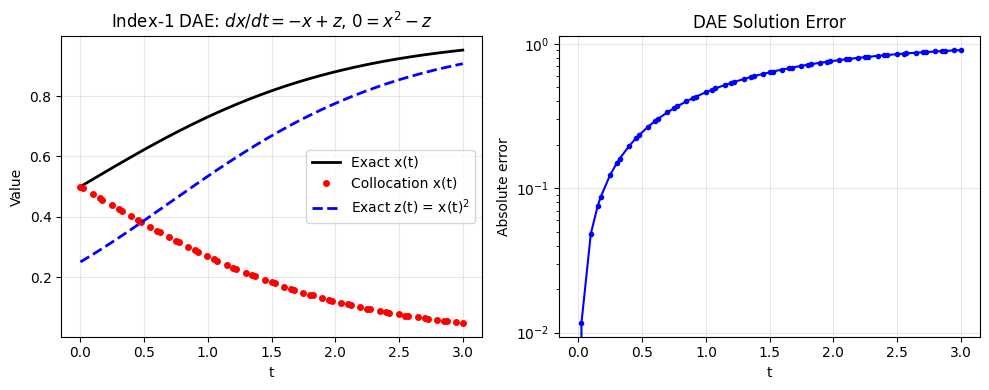

Max error in x: 9.05e-01


In [8]:
m = Model("index1_dae")
cs = ContinuousSet("t", bounds=(0, 3), nfe=20, ncp=3)
dae = DAEBuilder(m, cs)

dae.add_state("x", initial=0.5, bounds=(0, 2))
dae.add_algebraic("z", bounds=(0, 4))

# ODE: dx/dt = -x + z
dae.set_ode(lambda t, s, a, c: {"x": -s["x"] + a["z"]})

# Algebraic: 0 = x^2 - z
dae.set_algebraic(lambda t, s, a, c: {"z": s["x"] ** 2 - a["z"]})

dae.discretize()
m.minimize(0)
result = m.solve()

print(f"Status: {result.status}")

t_x, x_sol = dae.extract_solution(result, "x")

# Exact solution: dx/dt = -x + x^2 is a Bernoulli equation.
# With substitution y = 1/x: dy/dt = 1 - y, y(0) = 1/x(0) = 2
# y(t) = 1 + (y0 - 1)*exp(-t) = 1 + exp(-t)
# x(t) = 1 / (1 + exp(-t))
x0 = 0.5
y0 = 1.0 / x0
t_fine = np.linspace(0, 3, 200)
y_exact = 1.0 + (y0 - 1.0) * np.exp(-t_fine)
x_exact = 1.0 / y_exact
z_exact = x_exact**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(t_fine, x_exact, "k-", linewidth=2, label="Exact x(t)")
ax1.plot(t_x, x_sol, "ro", markersize=4, label="Collocation x(t)")
ax1.plot(t_fine, z_exact, "b--", linewidth=2, label="Exact z(t) = x(t)$^2$")
ax1.set_xlabel("t")
ax1.set_ylabel("Value")
ax1.set_title("Index-1 DAE: $dx/dt = -x + z$, $0 = x^2 - z$")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Verify algebraic constraint holds
y_exact_nodes = 1.0 + (y0 - 1.0) * np.exp(-t_x)
x_exact_nodes = 1.0 / y_exact_nodes
error = np.abs(x_sol - x_exact_nodes)

ax2.semilogy(t_x, error, "bo-", markersize=3)
ax2.set_xlabel("t")
ax2.set_ylabel("Absolute error")
ax2.set_title("DAE Solution Error")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max error in x: {np.max(error):.2e}")

## 8. Method of Lines: 1D Heat Equation

The **method of lines** (MOL) converts a PDE into a system of ODEs by
discretizing the spatial domain and leaving the time domain continuous.
For the 1D heat equation:

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}, \quad T(0,t) = 0, \; T(1,t) = 0, \; T(x,0) = \sin(\pi x)$$

we discretize the spatial domain $[0, 1]$ into $N$ interior points using
central differences for $\partial^2 T / \partial x^2$, yielding an ODE system:

$$\frac{dT_i}{dt} = \alpha \frac{T_{i-1} - 2T_i + T_{i+1}}{\Delta x^2}$$

with $T_0 = T_{N+1} = 0$ (boundary conditions).

The `n_components` parameter in `add_state()` lets us represent the spatial
grid as a vector-valued state.

Status: optimal


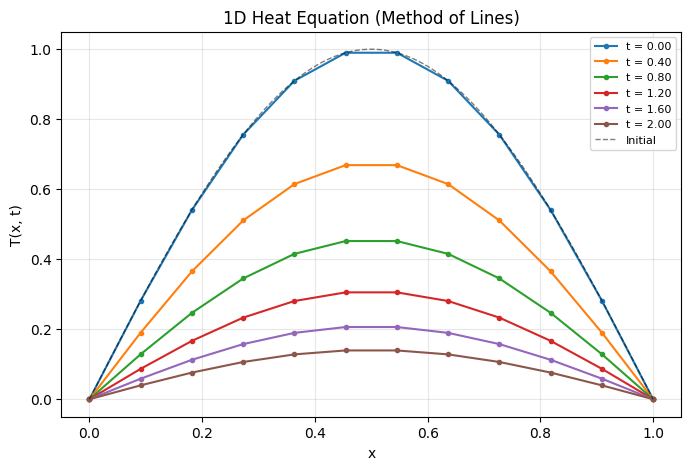

Max error at t=2.00 (vs exact PDE solution): 1.8522e-03
(Error includes spatial discretization from central differences)


In [9]:
alpha = 0.1  # thermal diffusivity
N = 10  # interior spatial points
dx = 1.0 / (N + 1)

# Spatial grid (interior points only; boundaries are fixed at 0)
x_grid = np.linspace(dx, 1.0 - dx, N)

# Initial condition: T(x, 0) = sin(pi * x)
T0 = np.sin(np.pi * x_grid)

m = Model("heat_equation")
cs = ContinuousSet("t", bounds=(0, 2), nfe=15, ncp=3)
dae = DAEBuilder(m, cs)

# Vector-valued state: T has N components (one per spatial grid point)
dae.add_state("T", n_components=N, initial=T0, bounds=(-2, 2))


def heat_rhs(t, states, alg, ctrl):
    T = states["T"]  # list of N expressions
    dTdt = []
    for i in range(N):
        T_left = T[i - 1] if i > 0 else 0.0  # T=0 at left boundary
        T_right = T[i + 1] if i < N - 1 else 0.0  # T=0 at right boundary
        dTdt.append(alpha * (T_left - 2 * T[i] + T_right) / dx**2)
    return {"T": dTdt}


dae.set_ode(heat_rhs)
dae.discretize()
m.minimize(0)
result = m.solve()

print(f"Status: {result.status}")

# Extract solution at several time snapshots
t_sol, T_sol = dae.extract_solution(result, "T")

# Add boundary points for plotting
x_full = np.concatenate([[0], x_grid, [1]])

# Plot several time snapshots
plt.figure(figsize=(8, 5))
n_snapshots = 6
snapshot_indices = np.linspace(0, len(t_sol) - 1, n_snapshots, dtype=int)

for idx in snapshot_indices:
    T_interior = T_sol[idx, :]
    T_full = np.concatenate([[0], T_interior, [0]])  # add boundary values
    plt.plot(x_full, T_full, "o-", markersize=3, label=f"t = {t_sol[idx]:.2f}")

# Exact solution: T(x,t) = sin(pi*x) * exp(-alpha*pi^2*t)
x_fine = np.linspace(0, 1, 100)
plt.plot(x_fine, np.sin(np.pi * x_fine), "k--", linewidth=1, alpha=0.5, label="Initial")

plt.xlabel("x")
plt.ylabel("T(x, t)")
plt.title("1D Heat Equation (Method of Lines)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

# Check against exact solution at final time
t_final = t_sol[-1]
T_exact_final = np.sin(np.pi * x_grid) * np.exp(-alpha * np.pi**2 * t_final)
T_num_final = T_sol[-1, :]
mol_error = np.max(np.abs(T_num_final - T_exact_final))
print(f"Max error at t={t_final:.2f} (vs exact PDE solution): {mol_error:.4e}")
print("(Error includes spatial discretization from central differences)")

## 9. Finite-Difference Discretization

For problems where high-order accuracy is not needed, **finite differences**
offer a simpler alternative to collocation. The `FDBuilder` class provides
the same high-level interface as `DAEBuilder` but uses finite-difference
stencils (backward Euler, forward Euler, or central differences) instead of
orthogonal collocation.

State variables have shape `(nfe + 1,)` --- values at all grid points including
both endpoints. Controls are piecewise constant per interval.

Let's solve the same exponential decay $dx/dt = -x$ using backward Euler
and compare accuracy with the collocation approach.

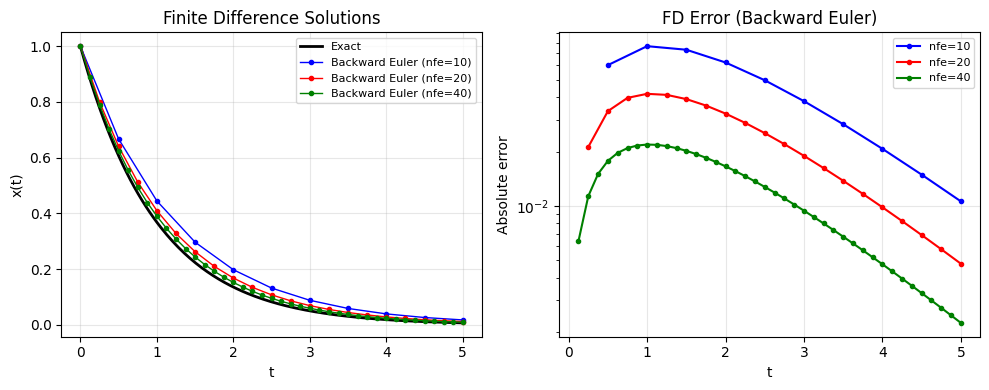


=== Accuracy comparison (nfe=20) ===


Collocation (nfe=20, ncp=3): max error = 3.71e-06  (80 variables)
Backward Euler (nfe=20):     max error = 4.17e-02  (21 variables)

Collocation achieves much higher accuracy for similar problem size,
but finite differences are simpler and work well for coarse approximations.


In [10]:
nfe_values = [10, 20, 40]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

t_exact = np.linspace(0, 5, 200)
x_exact = np.exp(-t_exact)
axes[0].plot(t_exact, x_exact, "k-", linewidth=2, label="Exact")

colors = ["b", "r", "g"]

for nfe, color in zip(nfe_values, colors):
    # FDBuilder uses backward Euler by default
    m_fd = Model(f"fd_{nfe}")
    cs_fd = ContinuousSet("t", bounds=(0, 5), nfe=nfe)
    fd = FDBuilder(m_fd, cs_fd, method="backward")

    fd.add_state("x", initial=1.0, bounds=(0, 2))
    fd.set_ode(lambda t, states, alg, ctrl: {"x": -states["x"]})
    fd.discretize()
    m_fd.minimize(0)
    result_fd = m_fd.solve()

    t_fd, x_fd = fd.extract_solution(result_fd, "x")
    error_fd = np.abs(x_fd - np.exp(-t_fd))

    axes[0].plot(
        t_fd, x_fd, f"{color}o-", markersize=3, linewidth=1, label=f"Backward Euler (nfe={nfe})"
    )
    axes[1].semilogy(t_fd[1:], error_fd[1:], f"{color}o-", markersize=3, label=f"nfe={nfe}")

axes[0].set_xlabel("t")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Finite Difference Solutions")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("t")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("FD Error (Backward Euler)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare FD vs collocation accuracy
print("\n=== Accuracy comparison (nfe=20) ===")

# Collocation with nfe=20, ncp=3
m_coll = Model("coll_compare")
cs_coll = ContinuousSet("t", bounds=(0, 5), nfe=20, ncp=3)
dae_coll = DAEBuilder(m_coll, cs_coll)
dae_coll.add_state("x", initial=1.0, bounds=(0, 2))
dae_coll.set_ode(lambda t, s, a, c: {"x": -s["x"]})
dae_coll.discretize()
m_coll.minimize(0)
r_coll = m_coll.solve()
t_c, x_c = dae_coll.extract_solution(r_coll, "x")
err_coll = np.max(np.abs(x_c - np.exp(-t_c)))

# FD with nfe=20
m_fd2 = Model("fd_compare")
cs_fd2 = ContinuousSet("t", bounds=(0, 5), nfe=20)
fd2 = FDBuilder(m_fd2, cs_fd2, method="backward")
fd2.add_state("x", initial=1.0, bounds=(0, 2))
fd2.set_ode(lambda t, s, a, c: {"x": -s["x"]})
fd2.discretize()
m_fd2.minimize(0)
r_fd2 = m_fd2.solve()
t_f, x_f = fd2.extract_solution(r_fd2, "x")
err_fd = np.max(np.abs(x_f - np.exp(-t_f)))

print(f"Collocation (nfe=20, ncp=3): max error = {err_coll:.2e}  ({20 * 4} variables)")
print(f"Backward Euler (nfe=20):     max error = {err_fd:.2e}  (21 variables)")
print("\nCollocation achieves much higher accuracy for similar problem size,")
print("but finite differences are simpler and work well for coarse approximations.")

## Summary

The `discopt.dae` module provides two discretization approaches for dynamic
optimization:

| Feature | `DAEBuilder` (collocation) | `FDBuilder` (finite difference) |
|---------|---------------------------|--------------------------------|
| Accuracy | High-order ($2n_{cp}-1$ for Radau) | First-order (Euler) |
| Algebraic variables | Yes (`add_algebraic`) | No |
| Second-order ODEs | Yes (`add_second_order_state`) | No |
| Integral objectives | Yes (`dae.integral()`) | Manual summation |
| Least-squares fitting | Yes (`dae.least_squares()`) | Yes (`fd.least_squares()`) |
| Non-uniform elements | Yes (`element_boundaries`) | Yes (`element_boundaries`) |
| Problem size | Larger (more variables per element) | Smaller |
| Best for | High-accuracy, stiff systems, DAEs | Quick prototyping, simple ODEs |

Key API methods:

- `ContinuousSet(name, bounds, nfe, ncp, scheme, element_boundaries)` --- define the time domain
- `align_time_grid(t_span, nfe, measurement_times)` --- snap element boundaries to measurement times
- `add_state(name, initial, bounds, n_components)` --- differential states
- `add_algebraic(name, bounds)` --- algebraic variables (DAEBuilder only)
- `add_control(name, bounds)` --- piecewise-constant controls
- `set_ode(rhs)` --- first-order ODE right-hand side
- `set_algebraic(rhs)` --- algebraic equations
- `set_second_order_ode(rhs)` --- acceleration for second-order ODEs
- `discretize()` --- generate all variables and constraints
- `least_squares(state_name, t_data, y_data)` --- sum-of-squared-residuals objective
- `extract_solution(result, name)` --- extract time series from solve result
- `integral(integrand)` --- quadrature-based integral expression

### References

- {cite:t}`Biegler2010` -- Nonlinear programming textbook with extensive coverage of collocation methods.
- {cite:t}`Betts2010` -- Practical methods for optimal control using direct transcription.
- {cite:t}`Cuthrell1987` -- Original simultaneous collocation approach for DAE-constrained optimization.